#                                         Solay Panel Defect Detection

In [1]:


# Install known-compatible versions
!pip install \
numpy \
scipy \
matplotlib \
pandas \
opencv-python \
roboflow \
ultralytics


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.7/91.7 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 39.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 50.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 46.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.2/4.2 MB 91.3 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.12.0.88
    Uninstalling opencv-python-headless-4.12.0.88:
      Successfully uninstalled opencv-python-headless-4.12.0.88
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency c

# **Import the required libraries and initialize the model**

In [2]:
import os
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from roboflow import Roboflow
from ultralytics import YOLO
from collections import Counter
from glob import glob
import yaml
print('all libraries are imported')

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
all libraries are imported


# Data Load

In [3]:

from roboflow import Roboflow
rf = Roboflow(api_key="1LXmrHIjxoP1M8QXA59l")
project = rf.workspace("pv-machine-vision").project("solar-panel-faults")
version = project.version(2)
dataset = version.download("yolo26")
                
                

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to solar-panel-faults-2 in yolo26:: 100%|██████████| 6446/6446 [00:01<00:00, 6112.04it/s]


In [4]:
# Update this to the actual downloaded folder name (it will be printed after download)
data_path = "/kaggle/working/solar-panel-faults-2"  
train_path = os.path.join(data_path, "train")
val_path = os.path.join(data_path, "valid")
test_path = os.path.join(data_path, "test")

# Load class names
with open(os.path.join(data_path, "data.yaml"), 'r') as f:
    data_yaml = yaml.safe_load(f)

class_names = data_yaml['names']
num_classes = len(class_names)
print(f"Classes ({num_classes}): {class_names}")

Classes (2): ['faulty', 'no faulty']


# Sample data display

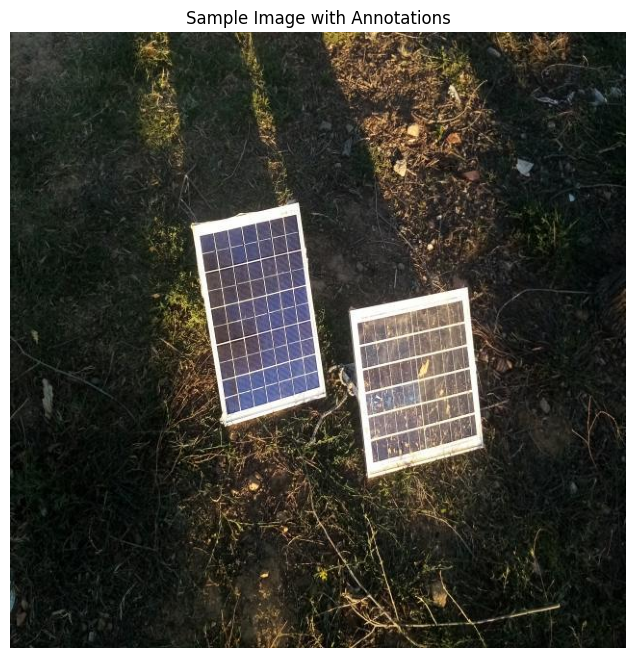

In [5]:
# Step 4: Sample data display
def display_sample_image(img_path, label_path):
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w, _ = img.shape
    
    if os.path.exists(label_path):
        with open(label_path, 'r') as f:
            labels = f.readlines()
        
        for label in labels:
            parts = label.strip().split()
            if len(parts) != 5:
                continue
            cls, x, y, bw, bh = map(float, parts)
            cls = int(cls)
            x1 = int((x - bw/2) * w)
            y1 = int((y - bh/2) * h)
            x2 = int((x + bw/2) * w)
            y2 = int((y + bh/2) * h)
            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)
            cv2.putText(img, class_names[cls], (x1, y1 - 10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (255, 0, 0), 2)
    
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Sample Image with Annotations")
    plt.show()

# Get a sample image
sample_imgs = glob(os.path.join(train_path, "images", "*.*"))  # supports jpg, png, etc.
if sample_imgs:
    sample_img = sample_imgs[50]
    sample_label = os.path.splitext(sample_img.replace("images", "labels"))[0] + ".txt"
    display_sample_image(sample_img, sample_label)
else:
    print("No images found in train folder.")

# EDA

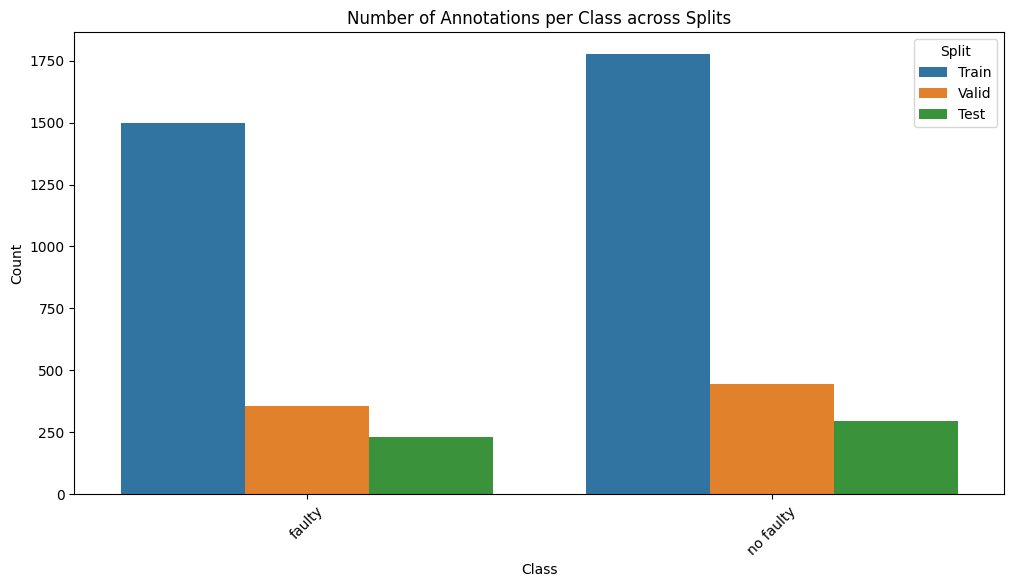

Train images: 2251
Valid images: 640
Test images: 326
Average bounding boxes per train image: 1.46


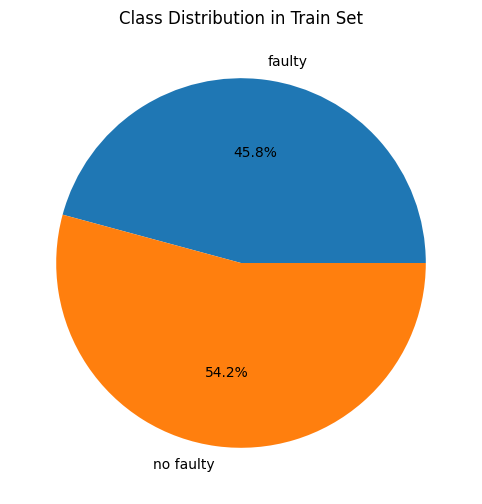

In [6]:
# Step 5: EDA - Number of images per class
# Function to count annotations per class
def count_per_class(label_dir):
    class_counts = Counter()
    for label_file in glob(os.path.join(label_dir, "*.txt")):
        with open(label_file, 'r') as f:
            labels = f.readlines()
            for label in labels:
                cls = int(label.strip().split()[0])
                class_counts[cls] += 1
    return class_counts

train_counts = count_per_class(os.path.join(train_path, "labels"))
val_counts = count_per_class(os.path.join(val_path, "labels"))
test_counts = count_per_class(os.path.join(test_path, "labels"))

# Create DataFrame for plotting
df = pd.DataFrame({
    "Class": class_names * 3,
    "Count": list(train_counts.values()) + list(val_counts.values()) + list(test_counts.values()),
    "Split": ["Train"] * num_classes + ["Valid"] * num_classes + ["Test"] * num_classes
})

# Plot
plt.figure(figsize=(12, 6))
sns.barplot(data=df, x="Class", y="Count", hue="Split")
plt.title("Number of Annotations per Class across Splits")
plt.xticks(rotation=45)
plt.show()

# More EDA: Number of images in each split
num_train_imgs = len(glob(os.path.join(train_path, "images", "*.jpg")))
num_val_imgs = len(glob(os.path.join(val_path, "images", "*.jpg")))
num_test_imgs = len(glob(os.path.join(test_path, "images", "*.jpg")))

print(f"Train images: {num_train_imgs}")
print(f"Valid images: {num_val_imgs}")
print(f"Test images: {num_test_imgs}")

# Average bounding boxes per image (for train)
total_bboxes_train = sum(train_counts.values())
avg_bboxes_train = total_bboxes_train / num_train_imgs if num_train_imgs > 0 else 0
print(f"Average bounding boxes per train image: {avg_bboxes_train:.2f}")

# Distribution of classes
plt.figure(figsize=(8, 6))
plt.pie(train_counts.values(), labels=class_names, autopct='%1.1f%%')
plt.title("Class Distribution in Train Set")
plt.show()

# **Train the model**

In [7]:
# Load YOLOv26n model
model = YOLO("yolo12n.pt")  # Pre-trained YOLOv8 nano model
# Train the YOLOv26 model
results = model.train(
    data = "/kaggle/working/solar-panel-faults-2/data.yaml",  # Path to dataset YAML file
    epochs = 50,           # Number of epochs
    imgsz = 640,           # Image size
    batch = 6,             # Batch size
    lr0 = 0.001,            # Initial learning rate
    workers = 2,           # Number of data loader workers
    optimizer = "AdamW",     # Optimizer (SGD or Adam)
    patience = 5,         # stop if no improvement for 5 epochs
    device = 0        # Device to use (0 for GPU, 'cpu' for CPU)
)

Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=6, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/solar-panel-faults-2/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolo12n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=AdamW, overlap_mask=True, patience=5, pe

# **Validate the model**

In [8]:
# Validation on the validation set (after training)
print("\nValidating the model on validation set...")
val_results = model.val()  # By default uses the 'val' split from your data.yaml

# Extract and print the key detection metrics
print(f"Validation mAP@0.5:      {val_results.box.map50:.4f}")
print(f"Validation mAP@0.5:0.95: {val_results.box.map:.4f}")


# Optional: Print per-class mAP@0.5
print("\nPer-class mAP@0.5:")
for i, class_name in enumerate(val_results.names.values()):
    class_map50 = val_results.box.maps[i] if hasattr(val_results.box, 'maps') else "N/A"
    print(f"  {class_name:12s}: {class_map50:.4f}")


Validating the model on validation set...
Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
YOLOv12n summary (fused): 159 layers, 2,557,118 parameters, 0 gradients, 6.3 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1623.0±371.5 MB/s, size: 76.3 KB)
val: Scanning /kaggle/working/solar-panel-faults-2/valid/labels.cache... 640 images, 4 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 640/640 244.0Mit/s 0.0s
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 537, len(boxes) = 802. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 40/40 6.4it/s 6.2s
                   all        640        802      0.916      0.844       0.93      0.845
                faulty        401        445      0.961

In [9]:
print("\nValidating the model on TEST set...")
test_results = model.val(split='test')  # Explicitly use the test split

print(f"Test mAP@0.5:      {test_results.box.map50:.4f}")
print(f"Test mAP@0.5:0.95: {test_results.box.map:.4f}")


Validating the model on TEST set...
Ultralytics 8.4.6 🚀 Python-3.12.12 torch-2.8.0+cu126 CUDA:0 (Tesla P100-PCIE-16GB, 16269MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 975.0±298.6 MB/s, size: 57.2 KB)
val: Scanning /kaggle/working/solar-panel-faults-2/test/labels... 326 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 326/326 1.2Kit/s 0.3s
val: New cache created: /kaggle/working/solar-panel-faults-2/test/labels.cache
WARNING ⚠️ Box and segment counts should be equal, but got len(segments) = 240, len(boxes) = 528. To resolve this only boxes will be used and all segments will be removed. To avoid this please supply either a detect or segment dataset, not a detect-segment mixed dataset.
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 21/21 5.0it/s 4.2s
                   all        326        528      0.802      0.701      0.826      0.681
                faulty        203        295      0.876      0.637      0.80

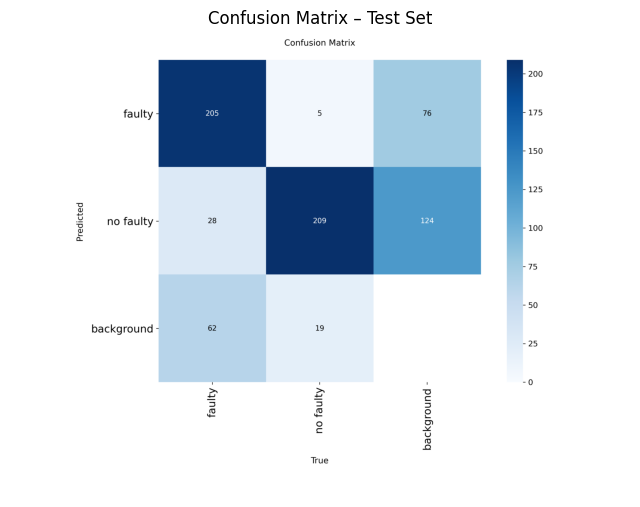

In [10]:
import matplotlib.pyplot as plt
import cv2

cm_path = "runs/detect/val2/confusion_matrix.png"

img = cv2.imread(cm_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(8, 8))
plt.imshow(img)
plt.axis("off")
plt.title("Confusion Matrix – Test Set")
plt.show()


# **Underfitting Vs Overfitting Plot**

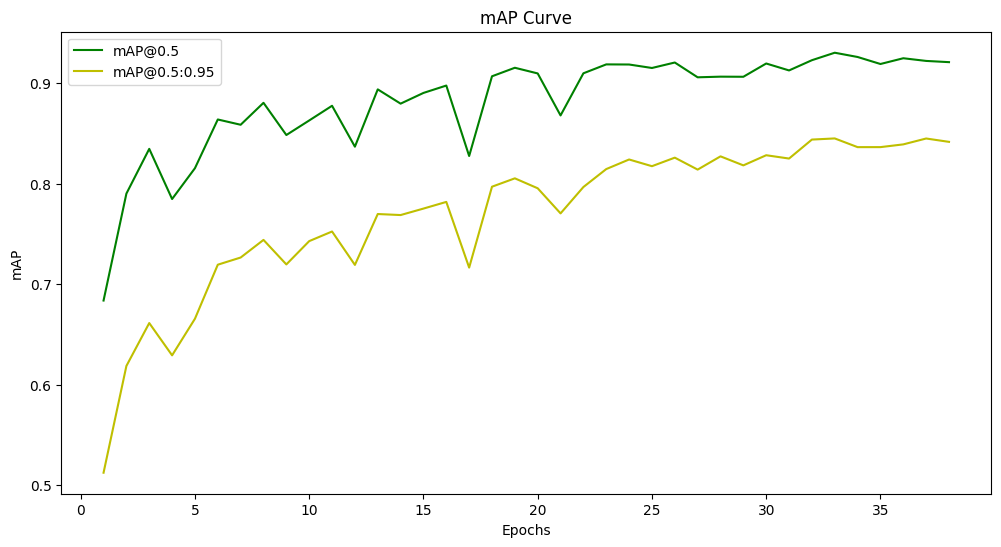

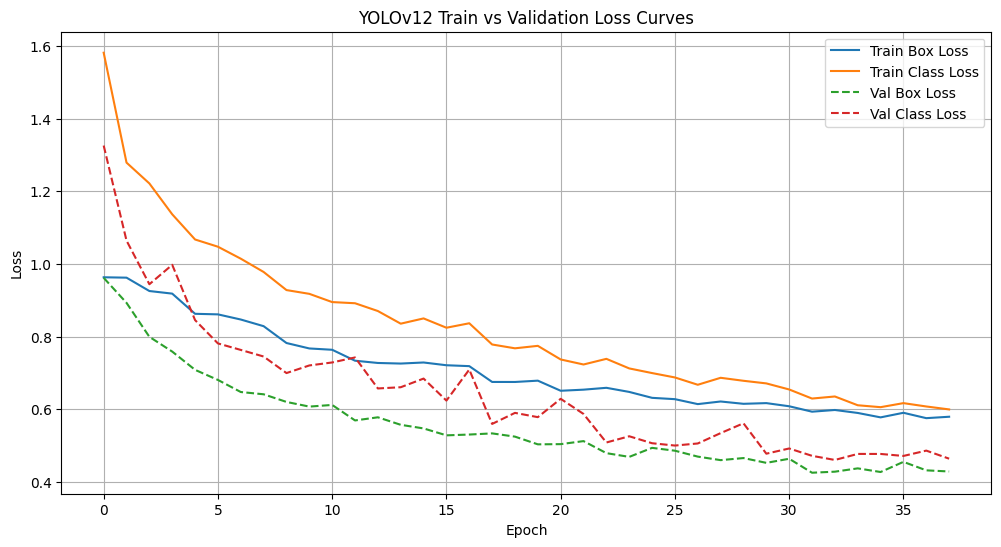

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Load training results
csv_path = "/kaggle/working/runs/detect/train/results.csv"  # Update path if needed
df = pd.read_csv(csv_path)


# Plot mAP curves
plt.figure(figsize = (12, 6)) # Set the figure size
plt.plot(df["epoch"], df["metrics/mAP50(B)"], label = "mAP@0.5", color = "g") # plot mAP@0.5 curve
plt.plot(df["epoch"], df["metrics/mAP50-95(B)"], label = "mAP@0.5:0.95", color = "y") # plot mAP@0.5:0.95 curve
plt.xlabel("Epochs") # Set the x-axis label
plt.ylabel("mAP")    # Set the y-axis label
plt.title("mAP Curve") # Set the title of the plot
plt.legend() # Show the legend
plt.show()   # Display the plot



results_df = pd.read_csv(csv_path)
plt.figure(figsize=(12, 6))

# Training losses
plt.plot(results_df["train/box_loss"], label="Train Box Loss")
plt.plot(results_df["train/cls_loss"], label="Train Class Loss")


# Validation losses
plt.plot(results_df["val/box_loss"], linestyle="--", label="Val Box Loss")
plt.plot(results_df["val/cls_loss"], linestyle="--", label="Val Class Loss")


plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("YOLOv12 Train vs Validation Loss Curves")
plt.legend()
plt.grid(True)
plt.show()



# **Test the model on new images**


image 1/1 /kaggle/working/solar-panel-faults-2/test/images/126_jpg.rf.e723f707eb4a3cb0612ddd96303a77de.jpg: 640x640 1 faulty, 14.3ms
Speed: 1.6ms preprocess, 14.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


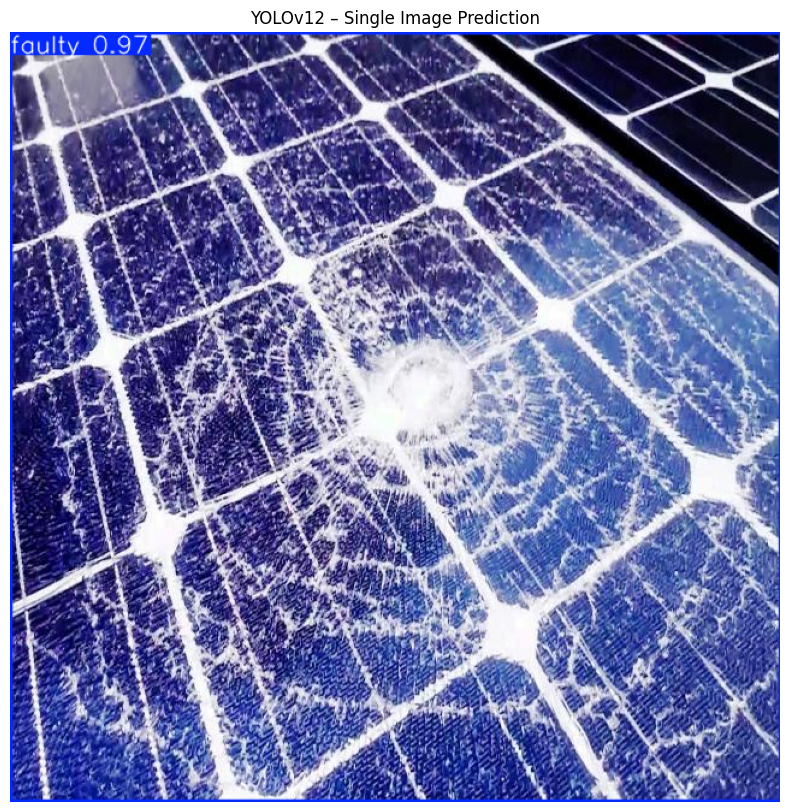

Detections:
- faulty | confidence: 0.97


In [12]:
# ===============================
# YOLOv26 SINGLE IMAGE INFERENCE
# ===============================

from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
import os

# -------------------------------
# 1. Paths (EDIT THESE)
# -------------------------------
model_path = "/kaggle/working/runs/detect/train/weights/best.pt"
image_path = "/kaggle/working/solar-panel-faults-2/test/images/126_jpg.rf.e723f707eb4a3cb0612ddd96303a77de.jpg"

# Safety checks
assert os.path.exists(model_path), "Model file not found"
assert os.path.exists(image_path), "Image file not found"

# -------------------------------
# 2. Load trained model
# -------------------------------
model = YOLO(model_path)

# -------------------------------
# 3. Run prediction on ONE image
# -------------------------------
results = model.predict(
    source=image_path,
    imgsz=640,
    conf=0.50,
    device=0
)

# -------------------------------
# 4. Display prediction (FIXED COLORS)
# -------------------------------
annotated_img = results[0].plot()

# Convert BGR → RGB for correct colors
annotated_img = cv2.cvtColor(annotated_img, cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 10))
plt.imshow(annotated_img)
plt.axis("off")
plt.title("YOLOv12 – Single Image Prediction")
plt.show()

# -------------------------------
# 5. Print detected objects
# -------------------------------
print("Detections:")
for box in results[0].boxes:
    cls_id = int(box.cls[0])
    conf = float(box.conf[0])
    class_name = model.names[cls_id]
    print(f"- {class_name} | confidence: {conf:.2f}")


# **mAP Comparion**

Test mAP@0.5:      0.8264
Test mAP@0.5:0.95: 0.6809


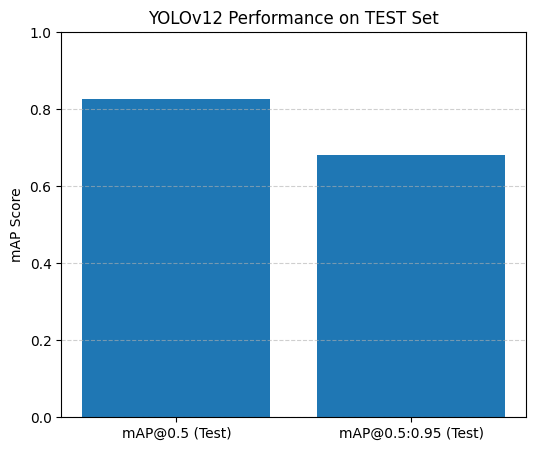

In [13]:
import matplotlib.pyplot as plt

# Extract mAP values
map_50 = test_results.box.map50
map_5095 = test_results.box.map

# Print values
print(f"Test mAP@0.5:      {map_50:.4f}")
print(f"Test mAP@0.5:0.95: {map_5095:.4f}")

# -------------------------------
# Bar plot for Test mAP
# -------------------------------
plt.figure(figsize=(6, 5))
plt.bar(
    ["mAP@0.5 (Test)", "mAP@0.5:0.95 (Test)"],
    [map_50, map_5095]
)

plt.ylim(0, 1)
plt.ylabel("mAP Score")
plt.title("YOLOv12 Performance on TEST Set")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.show()


# Model structure

In [14]:
print(model.model)

DetectionModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): ModuleList(
        (0): Bottleneck(
          (cv1): Conv(
            (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
        )
      )
    )
    (3): Conv(
      (conv): Conv2d(64,

In [15]:
!zip -r YOLOv26_solarpaneldefect_detection_weights.zip /kaggle/working/runs


  adding: kaggle/working/runs/ (stored 0%)
  adding: kaggle/working/runs/detect/ (stored 0%)
  adding: kaggle/working/runs/detect/val/ (stored 0%)
  adding: kaggle/working/runs/detect/val/val_batch0_pred.jpg (deflated 5%)
  adding: kaggle/working/runs/detect/val/BoxF1_curve.png (deflated 12%)
  adding: kaggle/working/runs/detect/val/BoxPR_curve.png (deflated 17%)
  adding: kaggle/working/runs/detect/val/val_batch0_labels.jpg (deflated 6%)
  adding: kaggle/working/runs/detect/val/val_batch1_pred.jpg (deflated 8%)
  adding: kaggle/working/runs/detect/val/val_batch2_pred.jpg (deflated 4%)
  adding: kaggle/working/runs/detect/val/confusion_matrix.png (deflated 31%)
  adding: kaggle/working/runs/detect/val/BoxP_curve.png (deflated 13%)
  adding: kaggle/working/runs/detect/val/confusion_matrix_normalized.png (deflated 30%)
  adding: kaggle/working/runs/detect/val/val_batch1_labels.jpg (deflated 8%)
  adding: kaggle/working/runs/detect/val/val_batch2_labels.jpg (deflated 5%)
  adding: kaggle/